# 07. Large-object confidence ranking diagnostics

기존 baseline/shared-E2E seed 42/43/44 checkpoint에서 Large 객체의 matched-query confidence와 unmatched-query confidence를 비교합니다. **학습과 optimizer step은 수행하지 않습니다.**

- `S_TP = P(c_GT | Hungarian-matched query for a Large GT)`
- `S_FP = max_c P(c | query unmatched to every GT)`

모든 GT를 함께 Hungarian matching한 뒤 Large GT에 배정된 query만 TP 쪽에 사용합니다. 따라서 Small/Medium GT에 정상 배정된 query를 FP로 잘못 세지 않습니다. 여기서 `matched_large`는 COCO TP 판정 자체가 아니라 학습 matcher가 Large GT에 배정한 query를 뜻합니다.


In [1]:
from pathlib import Path
import gc, importlib, json, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoImageProcessor
from transformers.loss.loss_deformable_detr import DeformableDetrHungarianMatcher

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.eval as eval_module
import gt_aux.model as model_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
eval_module = importlib.reload(eval_module)
model_module = importlib.reload(model_module)

ExperimentConfig = config_module.ExperimentConfig
DataBundle = data_module.DataBundle
VOCDataset = data_module.VOCDataset
collate_detection_batch = data_module.collate_detection_batch
parse_voc_record = data_module.parse_voc_record
load_checkpoint = eval_module.load_checkpoint
box_iou = model_module.box_iou
cxcywh_to_xyxy = model_module.cxcywh_to_xyxy


d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 설정

Validation 100장 전체와 세 seed를 사용합니다. 첫 실행 후 `RUN_DIAGNOSTICS=False`로 바꾸면 저장된 CSV만 읽어 표와 그래프를 다시 만들 수 있습니다.


In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_e2e']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, NUM_WORKERS = 2, 0
IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 384, 640
FEATURE_LEVEL = 0
RUN_DIAGNOSTICS = True

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    image_min_size=IMAGE_MIN_SIZE, image_max_size=IMAGE_MAX_SIZE,
    feature_level=FEATURE_LEVEL,
)
SEED_TAG = '-'.join(map(str, SEEDS))
OUT = CONFIG.output_dir
QUERY_PATH = OUT / f'large_confidence_queries_seeds{SEED_TAG}.csv'
IMAGE_PATH = OUT / f'large_confidence_images_seeds{SEED_TAG}.csv'
SEED_SUMMARY_PATH = OUT / f'large_confidence_seed_summary_seeds{SEED_TAG}.csv'
SUMMARY_FIGURE_PATH = OUT / f'large_confidence_summary_seeds{SEED_TAG}.png'
DISTRIBUTION_FIGURE_PATH = OUT / f'large_confidence_distributions_seeds{SEED_TAG}.png'
CONFIG.as_dict()


{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['baseline', 'shared_e2e'],
 'seed': 42,
 'data_seed': 42}

## 기존 split과 checkpoint 확인

기존 manifest를 읽어 학습 때와 동일한 validation subset을 복원합니다. 기존 checkpoint와 결과 파일은 수정하지 않습니다.


In [3]:
MANIFEST_PATH = OUT / 'voc2007_split_manifest.json'
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(MANIFEST_PATH)
manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
if manifest.get('data_seed') != DATA_SEED:
    raise ValueError(f"manifest data_seed={manifest.get('data_seed')} != {DATA_SEED}")

checkpoint_rows = []
for seed in SEEDS:
    for experiment in EXPERIMENTS:
        path = CONFIG.checkpoint_path(experiment, seed)
        checkpoint_rows.append({
            'experiment': experiment, 'seed': seed, 'exists': path.exists(),
            'size_mb': path.stat().st_size / 1024**2 if path.exists() else np.nan,
            'path': str(path),
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)
if not checkpoint_df['exists'].all():
    missing = checkpoint_df.loc[~checkpoint_df['exists'], 'path'].tolist()
    raise FileNotFoundError('Missing checkpoints:\n' + '\n'.join(missing))

val_ids = manifest['full_val_ids'][:VAL_IMAGES]
val_records = [parse_voc_record(CONFIG, str(image_id)) for image_id in tqdm(val_ids, desc='VOC val XML')]
try:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint, local_files_only=True)
except OSError:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint)
BUNDLE = DataBundle(processor, [], val_records, [], val_records)
collate_fn = lambda batch: collate_detection_batch(batch, BUNDLE.processor, CONFIG)
VAL_LOADER = DataLoader(
    VOCDataset(BUNDLE.val_records, CONFIG, training=False),
    batch_size=CONFIG.batch_size, shuffle=False, num_workers=CONFIG.num_workers,
    pin_memory=torch.cuda.is_available(), collate_fn=collate_fn,
)
print({'val_images': len(val_records), 'val_batches': len(VAL_LOADER), 'device': str(CONFIG.device)})


,experiment,seed,exists,size_mb,path
0,baseline,42,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
1,shared_e2e,42,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...
2,baseline,43,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
3,shared_e2e,43,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...
4,baseline,44,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...
5,shared_e2e,44,True,461.330661,D:\gt-super\cache\checkpoints\checkpoint_smoke...


VOC val XML: 100%|██████████| 100/100 [00:00<00:00, 3175.87it/s]

{'val_images': 100, 'val_batches': 50, 'device': 'cuda'}


In [4]:
def large_mask(boxes_xyxy):
    wh = (boxes_xyxy[:, 2:] - boxes_xyxy[:, :2]).clamp(min=0)
    return wh[:, 0] * wh[:, 1] >= 96**2

def release_model(model):
    model.close()
    model.cpu()
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## Large matched-query vs unmatched-query confidence 수집

`S_FP` 전체 평균은 수많은 저신뢰 query에 희석될 수 있으므로 이미지별 FP 평균과 함께 q95, q99, top-10 평균, 최대값도 저장합니다. `duplicate_like_fp50`은 unmatched query의 최고-score class와 같은 GT에 IoU≥0.5인 경우로, 후속 duplicate 분석을 위한 보조 지표입니다.


In [5]:
@torch.inference_mode()
def collect_confidence_diagnostics(experiment, seed):
    model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    model.eval()
    detector_config = model.detector.config
    matcher = DeformableDetrHungarianMatcher(
        class_cost=detector_config.class_cost, bbox_cost=detector_config.bbox_cost,
        giou_cost=detector_config.giou_cost,
    )
    query_rows, image_rows = [], []
    try:
        for batch in tqdm(VAL_LOADER, desc=f'{experiment}/seed{seed}', leave=False):
            pixel_values = batch['pixel_values'].to(CONFIG.device, non_blocking=True)
            pixel_mask = batch['pixel_mask'].to(CONFIG.device, non_blocking=True)
            labels = [
                {key: value.to(CONFIG.device) for key, value in target.items()}
                for target in batch['labels']
            ]
            result = model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=None)
            outputs = result['outputs']
            match_indices = matcher(
                {'logits': outputs.logits, 'pred_boxes': outputs.pred_boxes}, labels,
            )

            for image_offset, ((source_indices, target_indices), target, eval_target) in enumerate(
                zip(match_indices, labels, batch['eval_targets'])
            ):
                target_large_mask = large_mask(eval_target['boxes'])
                if not target_large_mask.any():
                    continue
                image_id = int(eval_target['image_id'])
                source_indices = source_indices.to(CONFIG.device)
                target_indices_device = target_indices.to(CONFIG.device)
                probabilities = outputs.logits[image_offset].sigmoid()
                predicted_boxes = outputs.pred_boxes[image_offset]
                query_count = probabilities.shape[0]

                # Full-GT matching prevents valid Small/Medium assignments from entering the FP pool.
                matched_query_mask = torch.zeros(query_count, dtype=torch.bool, device=CONFIG.device)
                matched_query_mask[source_indices] = True
                matched_large_selector = target_large_mask[target_indices].to(CONFIG.device)
                large_source_indices = source_indices[matched_large_selector]
                large_target_indices = target_indices_device[matched_large_selector]
                large_target_classes = target['class_labels'][large_target_indices]
                large_target_scores = probabilities[large_source_indices, large_target_classes]
                large_query_max_scores, large_query_max_classes = probabilities[large_source_indices].max(dim=-1)
                large_predicted_boxes = predicted_boxes[large_source_indices]
                large_target_boxes = target['boxes'][large_target_indices]
                large_ious = torch.diag(box_iou(
                    cxcywh_to_xyxy(large_predicted_boxes), cxcywh_to_xyxy(large_target_boxes),
                )[0])

                for values in zip(
                    large_source_indices.cpu().tolist(), large_target_scores.cpu().tolist(),
                    large_query_max_scores.cpu().tolist(), large_ious.cpu().tolist(),
                    large_target_classes.cpu().tolist(), large_query_max_classes.cpu().tolist(),
                ):
                    query_index, target_score, max_score, matched_iou, target_class, max_class = values
                    query_rows.append({
                        'experiment': experiment, 'seed': seed, 'image_id': image_id,
                        'role': 'matched_large', 'query_index': query_index,
                        'score': target_score, 'query_max_score': max_score,
                        'matched_iou': matched_iou, 'target_class': target_class,
                        'max_class': max_class, 'class_correct': int(target_class == max_class),
                        'max_iou_same_class': matched_iou, 'duplicate_like_fp50': 0,
                    })

                unmatched_indices = torch.where(~matched_query_mask)[0]
                unmatched_scores, unmatched_classes = probabilities[unmatched_indices].max(dim=-1)
                unmatched_boxes = predicted_boxes[unmatched_indices]
                ious_to_gt = box_iou(
                    cxcywh_to_xyxy(unmatched_boxes), cxcywh_to_xyxy(target['boxes']),
                )[0]
                same_class = unmatched_classes[:, None] == target['class_labels'][None, :]
                same_class_ious = torch.where(same_class, ious_to_gt, ious_to_gt.new_full(ious_to_gt.shape, -1))
                max_iou_same_class = same_class_ious.max(dim=1).values.clamp(min=0)
                duplicate_like = max_iou_same_class >= 0.5

                fp_values = list(zip(
                    unmatched_indices.cpu().tolist(), unmatched_scores.cpu().tolist(),
                    unmatched_classes.cpu().tolist(), max_iou_same_class.cpu().tolist(),
                    duplicate_like.cpu().tolist(),
                ))
                for query_index, fp_score, max_class, same_class_iou, is_duplicate in fp_values:
                    query_rows.append({
                        'experiment': experiment, 'seed': seed, 'image_id': image_id,
                        'role': 'unmatched', 'query_index': query_index,
                        'score': fp_score, 'query_max_score': fp_score,
                        'matched_iou': np.nan, 'target_class': np.nan,
                        'max_class': max_class, 'class_correct': np.nan,
                        'max_iou_same_class': same_class_iou,
                        'duplicate_like_fp50': int(is_duplicate),
                    })

                fp_scores_np = unmatched_scores.cpu().numpy()
                top_count = min(10, len(fp_scores_np))
                top10_mean = float(np.partition(fp_scores_np, -top_count)[-top_count:].mean())
                tp_scores_np = large_target_scores.cpu().numpy()
                image_rows.append({
                    'experiment': experiment, 'seed': seed, 'image_id': image_id,
                    'large_gt_count': len(tp_scores_np),
                    'matched_tp_score_mean': float(tp_scores_np.mean()),
                    'matched_tp_score_min': float(tp_scores_np.min()),
                    'matched_iou_mean': float(large_ious.mean()),
                    'matched_class_accuracy': float((large_target_classes == large_query_max_classes).float().mean()),
                    'fp_query_count': len(fp_scores_np),
                    'fp_score_mean': float(fp_scores_np.mean()),
                    'fp_score_q95': float(np.quantile(fp_scores_np, 0.95)),
                    'fp_score_q99': float(np.quantile(fp_scores_np, 0.99)),
                    'fp_score_top10_mean': top10_mean,
                    'fp_score_max': float(fp_scores_np.max()),
                    'tp_minus_top_fp': float(tp_scores_np.mean() - fp_scores_np.max()),
                    'tp_above_top_fp': int(tp_scores_np.mean() > fp_scores_np.max()),
                    'duplicate_like_fp50_count': int(duplicate_like.sum()),
                    'duplicate_like_fp50_rate': float(duplicate_like.float().mean()),
                    'high_confidence_fp50_count': int((unmatched_scores >= 0.5).sum()),
                    'checkpoint_epoch': checkpoint.get('epoch'), 'fingerprint': fingerprint,
                })
        return query_rows, image_rows
    finally:
        release_model(model)


In [6]:
if RUN_DIAGNOSTICS:
    query_rows, image_rows = [], []
    for seed in SEEDS:
        for experiment in EXPERIMENTS:
            run_query_rows, run_image_rows = collect_confidence_diagnostics(experiment, seed)
            query_rows.extend(run_query_rows)
            image_rows.extend(run_image_rows)
    query_df = pd.DataFrame(query_rows)
    image_df = pd.DataFrame(image_rows)
    query_df.to_csv(QUERY_PATH, index=False)
    image_df.to_csv(IMAGE_PATH, index=False)
else:
    query_df = pd.read_csv(QUERY_PATH)
    image_df = pd.read_csv(IMAGE_PATH)
print('Saved/loaded:', QUERY_PATH, IMAGE_PATH)
print({
    'query_rows': len(query_df), 'large_image_rows': len(image_df),
    'matched_large_rows': int(query_df['role'].eq('matched_large').sum()),
    'unmatched_rows': int(query_df['role'].eq('unmatched').sum()),
})


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 18762.99it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

Saved/loaded: D:\gt-super\outputs\detr_gt_auxiliary\large_confidence_queries_seeds42-43-44.csv D:\gt-super\outputs\detr_gt_auxiliary\large_confidence_images_seeds42-43-44.csv
{'query_rows': 165138, 'large_image_rows': 552, 'matched_large_rows': 1140, 'unmatched_rows': 163998}


## Seed-level 비교표

각 이미지에서 먼저 요약한 뒤 seed별 평균을 계산합니다. 최종 표의 오차는 세 seed 사이의 표준편차입니다.


In [7]:
SUMMARY_METRICS = [
    'matched_tp_score_mean', 'matched_iou_mean', 'matched_class_accuracy',
    'fp_score_mean', 'fp_score_q95', 'fp_score_q99',
    'fp_score_top10_mean', 'fp_score_max', 'tp_minus_top_fp',
    'tp_above_top_fp', 'duplicate_like_fp50_rate', 'high_confidence_fp50_count',
]
seed_summary_df = image_df.groupby(['experiment', 'seed'], as_index=False)[SUMMARY_METRICS].mean()
seed_summary_df.to_csv(SEED_SUMMARY_PATH, index=False)
display(seed_summary_df.style.format({metric: '{:.4f}' for metric in SUMMARY_METRICS}))

summary_df = seed_summary_df.groupby('experiment')[SUMMARY_METRICS].agg(['mean', 'std'])
display(summary_df.style.format('{:.4f}'))

baseline_seed = (
    seed_summary_df.query("experiment == 'baseline'")
    [['seed'] + SUMMARY_METRICS]
    .rename(columns={metric: f'baseline_{metric}' for metric in SUMMARY_METRICS})
)
paired_delta_df = seed_summary_df.merge(baseline_seed, on='seed')
for metric in SUMMARY_METRICS:
    paired_delta_df[f'delta_{metric}'] = paired_delta_df[metric] - paired_delta_df[f'baseline_{metric}']
shared_delta = (
    paired_delta_df.query("experiment == 'shared_e2e'")
    [[f'delta_{metric}' for metric in SUMMARY_METRICS]].agg(['mean', 'std']).T
)
display(shared_delta.style.format('{:+.4f}').set_caption('Shared-E2E paired delta vs baseline'))
print('Saved:', SEED_SUMMARY_PATH)


,experiment,seed,matched_tp_score_mean,matched_iou_mean,matched_class_accuracy,fp_score_mean,fp_score_q95,fp_score_q99,fp_score_top10_mean,fp_score_max,tp_minus_top_fp,tp_above_top_fp,duplicate_like_fp50_rate,high_confidence_fp50_count
0,baseline,42,0.0937,0.8412,0.4571,0.0477,0.1121,0.1568,0.1509,0.1874,-0.0937,0.0109,0.0653,0.0000
1,baseline,43,0.1122,0.8479,0.4436,0.0435,0.1032,0.1494,0.1456,0.1975,-0.0853,0.0761,0.0464,0.0000
2,baseline,44,0.0869,0.8376,0.4001,0.0463,0.1092,0.1426,0.1391,0.1658,-0.0790,0.0000,0.0773,0.0000
3,shared_e2e,42,0.1035,0.8539,0.4392,0.0438,0.1135,0.1622,0.1550,0.1892,-0.0857,0.0326,0.0636,0.0000
4,shared_e2e,43,0.1069,0.8575,0.4562,0.0442,0.1112,0.1621,0.1549,0.1926,-0.0857,0.0217,0.0700,0.0000
5,shared_e2e,44,0.1015,0.8533,0.4571,0.0465,0.1095,0.1499,0.1451,0.1750,-0.0735,0.0435,0.0636,0.0000


,mean,std
delta_matched_tp_score_mean,+0.0064,+0.0104
delta_matched_iou_mean,+0.0127,+0.0031
delta_matched_class_accuracy,+0.0173,+0.0377
delta_fp_score_mean,-0.0010,+0.0025
delta_fp_score_q95,+0.0032,+0.0041
delta_fp_score_q99,+0.0085,+0.0038
delta_fp_score_top10_mean,+0.0065,+0.0026
delta_fp_score_max,+0.0020,+0.0070
delta_tp_minus_top_fp,+0.0043,+0.0043
delta_tp_above_top_fp,+0.0036,+0.0514


Saved: D:\gt-super\outputs\detr_gt_auxiliary\large_confidence_seed_summary_seeds42-43-44.csv


## Confidence·IoU·ranking 그래프

FP 막대는 전체 평균뿐 아니라 ranking을 실제로 교란하는 high-confidence tail을 보여주는 이미지별 q99와 최대값을 함께 표시합니다.


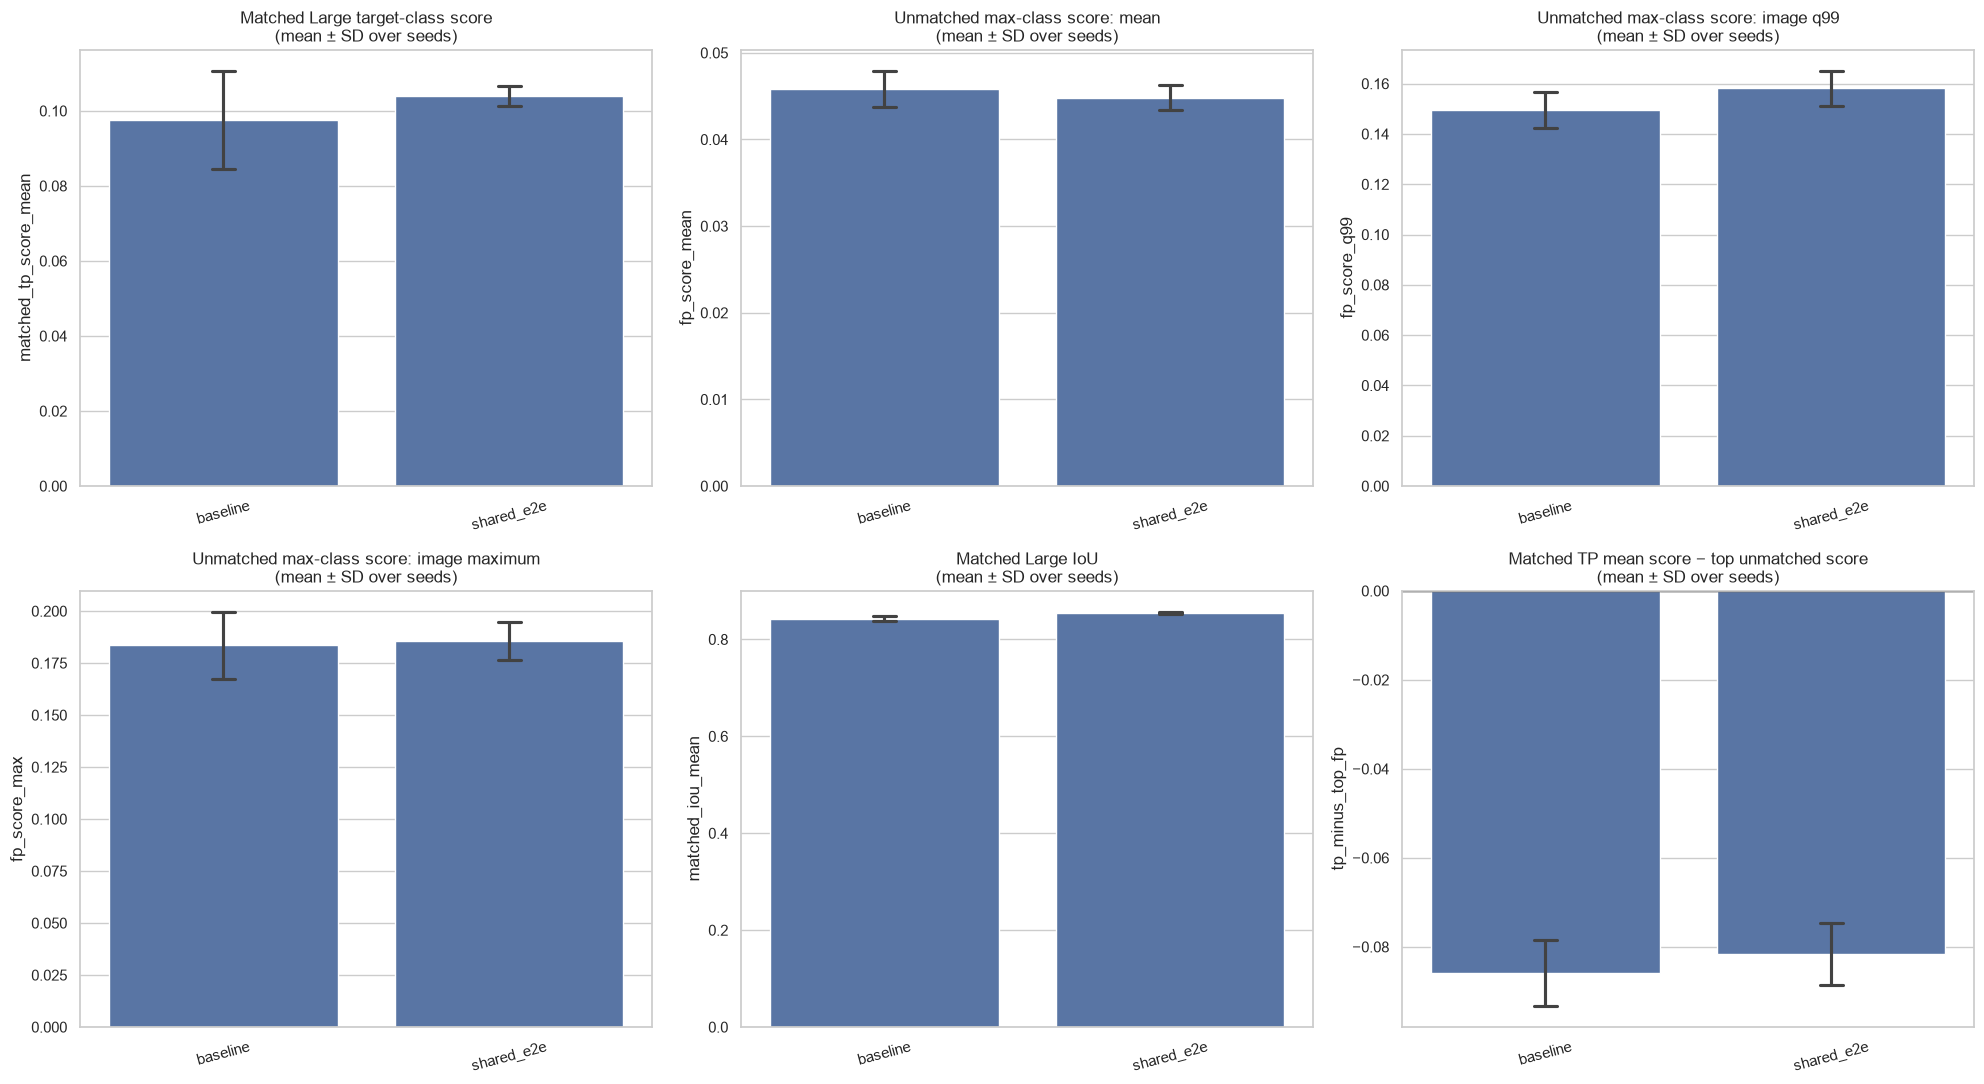

Saved: D:\gt-super\outputs\detr_gt_auxiliary\large_confidence_summary_seeds42-43-44.png


In [8]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
PLOT_SPECS = [
    ('matched_tp_score_mean', 'Matched Large target-class score'),
    ('fp_score_mean', 'Unmatched max-class score: mean'),
    ('fp_score_q99', 'Unmatched max-class score: image q99'),
    ('fp_score_max', 'Unmatched max-class score: image maximum'),
    ('matched_iou_mean', 'Matched Large IoU'),
    ('tp_minus_top_fp', 'Matched TP mean score − top unmatched score'),
]
for axis, (metric, title) in zip(axes.flat, PLOT_SPECS):
    sns.barplot(
        data=seed_summary_df, x='experiment', y=metric,
        estimator='mean', errorbar='sd', capsize=0.08, ax=axis,
    )
    axis.set_title(title + '\n(mean ± SD over seeds)')
    axis.set_xlabel('')
    axis.tick_params(axis='x', rotation=15)
    if metric == 'tp_minus_top_fp':
        axis.axhline(0, color='black', linewidth=1)
plt.tight_layout()
fig.savefig(SUMMARY_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', SUMMARY_FIGURE_PATH)


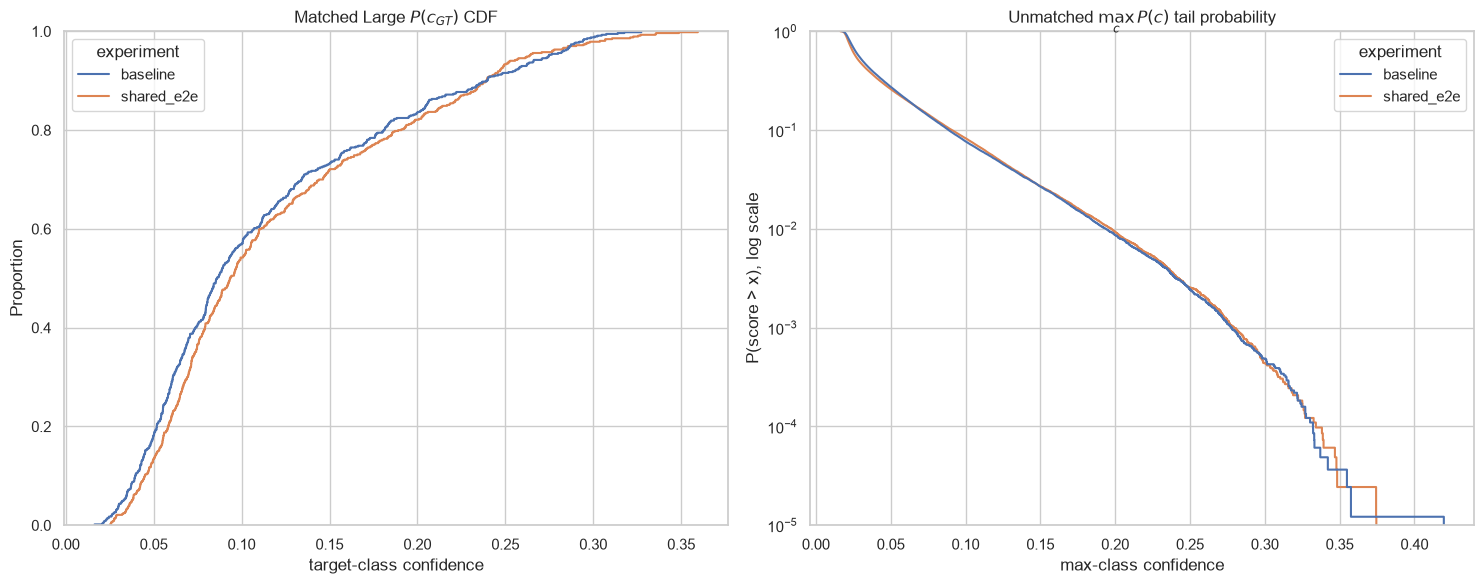

Saved: D:\gt-super\outputs\detr_gt_auxiliary\large_confidence_distributions_seeds42-43-44.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
matched_df = query_df.query("role == 'matched_large'")
unmatched_df = query_df.query("role == 'unmatched'")
sns.ecdfplot(data=matched_df, x='score', hue='experiment', ax=axes[0])
axes[0].set_title(r'Matched Large $P(c_{GT})$ CDF')
axes[0].set_xlabel('target-class confidence')
sns.ecdfplot(data=unmatched_df, x='score', hue='experiment', complementary=True, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_ylim(1e-5, 1)
axes[1].set_title(r'Unmatched $\max_c P(c)$ tail probability')
axes[1].set_xlabel('max-class confidence')
axes[1].set_ylabel('P(score > x), log scale')
plt.tight_layout()
fig.savefig(DISTRIBUTION_FIGURE_PATH, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', DISTRIBUTION_FIGURE_PATH)


## 자동 판정

방향성 판정은 세 seed 평균 기준입니다. `TP score↓ + FP high-confidence tail↑ + matched IoU↑`가 동시에 나오면 box geometry는 개선됐지만 confidence calibration/ranking이 악화됐다는 가설과 일치합니다.


In [10]:
delta_means = shared_delta['mean']
calibration_ranking_pattern = (
    delta_means['delta_matched_tp_score_mean'] < 0
    and delta_means['delta_fp_score_q99'] > 0
    and delta_means['delta_matched_iou_mean'] > 0
)
tp_confidence_normal = delta_means['delta_matched_tp_score_mean'] >= 0
print({
    'delta_matched_tp_score': float(delta_means['delta_matched_tp_score_mean']),
    'delta_fp_score_mean': float(delta_means['delta_fp_score_mean']),
    'delta_fp_score_q99': float(delta_means['delta_fp_score_q99']),
    'delta_fp_score_max': float(delta_means['delta_fp_score_max']),
    'delta_matched_iou': float(delta_means['delta_matched_iou_mean']),
    'delta_tp_minus_top_fp': float(delta_means['delta_tp_minus_top_fp']),
    'confidence_calibration_ranking_pattern': bool(calibration_ranking_pattern),
    'tp_confidence_normal_or_higher': bool(tp_confidence_normal),
})


{'delta_matched_tp_score': 0.006371722563399356, 'delta_fp_score_mean': -0.000999778401160586, 'delta_fp_score_q99': 0.008504221917710433, 'delta_fp_score_max': 0.0020416678077932646, 'delta_matched_iou': 0.012656378465286222, 'delta_tp_minus_top_fp': 0.004330054883831656, 'confidence_calibration_ranking_pattern': False, 'tp_confidence_normal_or_higher': True}
